In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [ ]:
def load_data(file_path):
    """Load data from a JSON file."""
    with open(file_path, 'r') as file:
        data = json.load(file)
    return pd.DataFrame(data)

def to_lower(df):
    return df.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

def prepare_for_analysis(filepath):
    df = load_data(filepath)
    df = df.transpose()
    df = to_lower(df)
    return df

def date_to_int(df, col_name):
    original_len = len(df)
    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
    df[col_name] = df[col_name].dt.year
    df = df.dropna(subset=[col_name]).astype({col_name: 'int'})
    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, Percentage kept: {final_len/original_len*100:.2f}%")

# def plot_timeline(df, col_name):
#     date_to_int(df, col_name)
#     plt.figure(figsize=(8, 4))
#     n_bins = df[col_name].nunique()
#     sns.histplot(df[col_name], bins=n_bins, kde=False, color='seagreen', edgecolor='darkgreen')
#     plt.xlabel(col_name)
#     plt.ylabel('Frequency')
#     ax = plt.gca()
#     ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
#     plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
#     plt.tight_layout()
#     plt.show()


In [149]:
EMA_path = "./../output/20250722_EMA_gpt-4o.json"
JAPAN_path = "./../output/20250722_Japan_gpt-4o.json"
SWISSMEDIC_path = "./../output/20250722_SwissMedic_gpt-4o.json"

EMA = prepare_for_analysis(EMA_path)
JAPAN = prepare_for_analysis(JAPAN_path)
SWISSMEDIC = prepare_for_analysis(SWISSMEDIC_path)

Original length: 1837, Final length after cleaning: 1566, Percentage kept: 85.25%


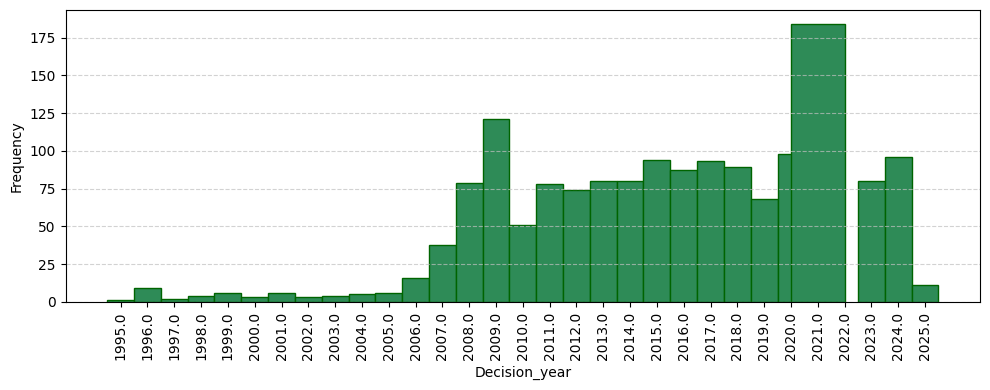

Original length: 378, Final length after cleaning: 378, Percentage kept: 100.00%


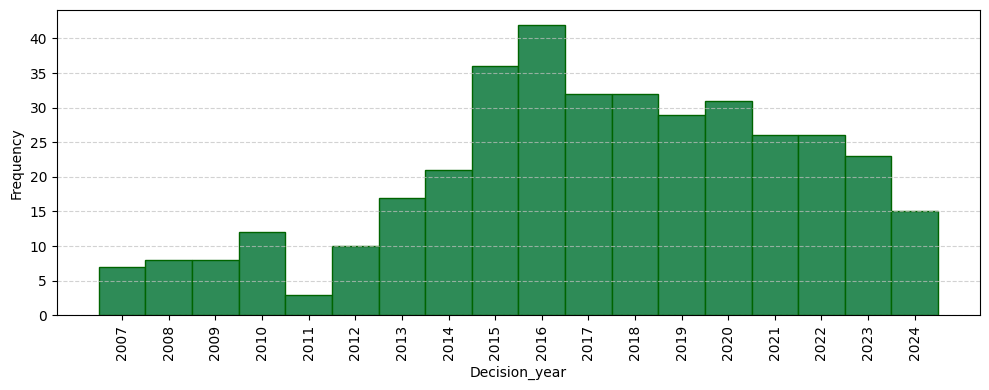

Original length: 170, Final length after cleaning: 170, Percentage kept: 100.00%


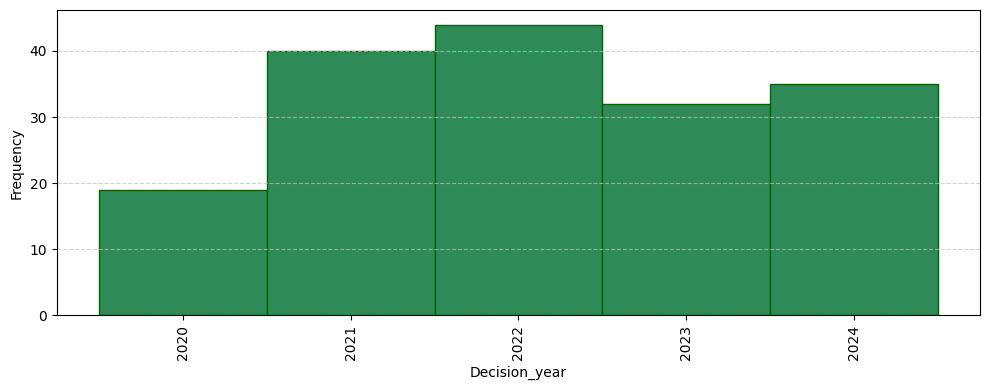

In [150]:
plot_timeline(EMA, col_name='Decision_year')
plot_timeline(JAPAN, col_name='Decision_year')
plot_timeline(SWISSMEDIC, col_name='Decision_year')